# RED-Diff tuning notebook

In [1]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from tqdm import tqdm
import torchvision.io as io
from PIL import Image
import os
from pathlib import Path

REPO_URL = "https://github.com/javiuv/GenNN-InverseMicro.git"
REPO_NAME = "GenNN-InverseMicro/"

if os.path.exists(REPO_NAME):
    !rm -rf {REPO_NAME}

!git clone {REPO_URL}
%cd {REPO_NAME}

!git fetch origin
!git checkout feature/red-diff-tuning


Cloning into 'GenNN-InverseMicro'...
remote: Enumerating objects: 239, done.
remote: Counting objects: 100% (239/239), done.
remote: Compressing objects: 100% (154/154), done.
remote: Total 239 (delta 117), reused 200 (delta 79), pack-reused 0 (from 0)
Receiving objects: 100% (239/239), 4.70 MiB | 17.77 MiB/s, done.
Resolving deltas: 100% (117/117), done.
/content/GenNN-InverseMicro
Branch 'feature/red-diff-tuning' set up to track remote branch 'feature/red-diff-tuning' from 'origin'.
Switched to a new branch 'feature/red-diff-tuning'


In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


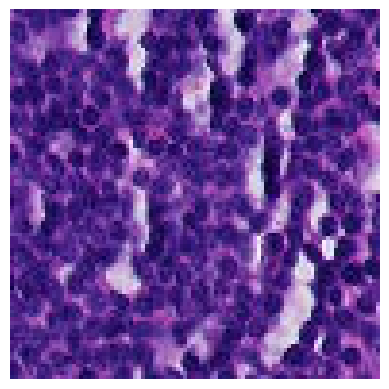

In [3]:
def show_tensor(tensor):
    img = (tensor.clamp(-1, 1) + 1) / 2
    img = img.squeeze(0).cpu().permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.axis('off')
    plt.show()

OUTPUT_DIR = Path("/content/drive/MyDrive/pcam_subset_ready/clean/test/")

# print(os.listdir(OUTPUT_DIR))
# example_clean = Image.open(OUTPUT_DIR / "test_0000.png")
imagen_tensor = io.read_image(OUTPUT_DIR / "test_0002.png")

input_image = imagen_tensor.float() / 255.
input_image = input_image*2-1
input_image = input_image.unsqueeze(0)

show_tensor(input_image)


In [11]:
from src.data.dataset import CleanImageDataset
from torchvision import transforms

import torch.nn.functional as F


dataset = CleanImageDataset(
    root_dir=OUTPUT_DIR,
    image_size=96
)
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=6,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

torch.Size([10, 3, 96, 96])


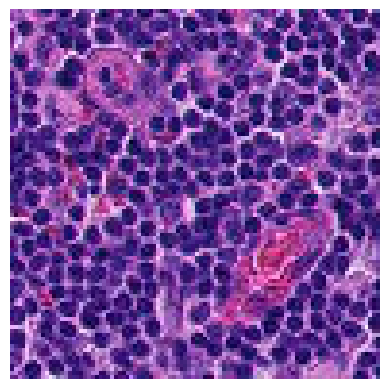

torch.Size([10, 3, 96, 96])


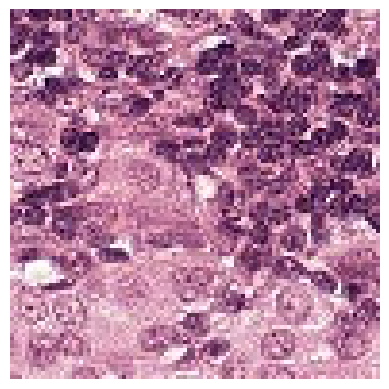

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for batch in dataloader:
  imagenes = batch.to(device)*2-1
  print(imagenes.shape)
  show_tensor(imagenes[0])


## RED-Diff inference

In [16]:
from main import run_experiment
from src.operators import Operator
import functools

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True

torch.load = functools.partial(torch.load, weights_only=False)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
H = Operator(channels=3, scale_factor=2).to(device)

reconstructions = []
originals = []

for batch in dataloader:
    batch_img = batch.to(device, non_blocking=True) * 2 - 1
    batch_128 = F.pad(batch_img, (16, 16, 16, 16), mode='constant', value=0)

    y_real = batch_128.to(device)

    img_noisy = H.forward(y_real)
    img_recon = run_experiment(img_noisy, method='red-diff')

    reconstructions.append(img_recon.detach().cpu())
    originals.append(y_real.detach().cpu())

    break

all_recons = torch.cat(reconstructions, dim=0)
all_originals = torch.cat(originals, dim=0)

def print_vram():
    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    print(f"VRAM assigned: {allocated:.2f} GB")
    print(f"VRAM reserved: {reserved:.2f} GB")

print_vram()

100%|██████████| 500/500 [03:11<00:00,  2.61it/s]


VRAM assigned: 0.01 GB
VRAM reserved: 4.29 GB


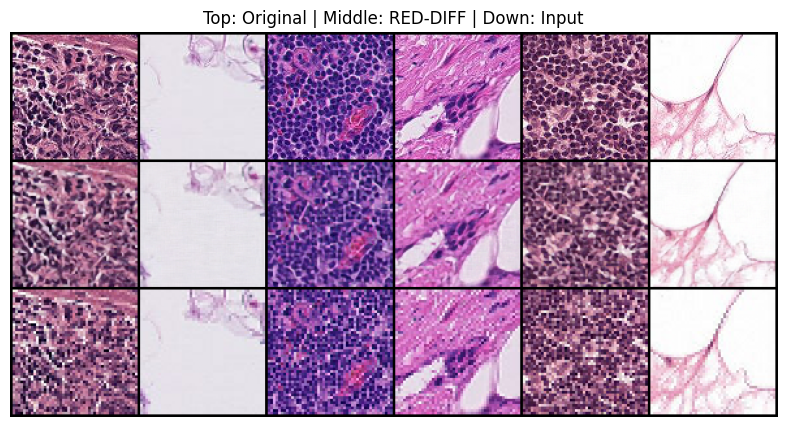

In [26]:
import matplotlib.pyplot as plt
import torch
import torchvision.utils as vutils

all_recons_norm = (all_recons + 1) / 2
all_originals_norm = (all_originals + 1) / 2

def show_comparison(originals, reconstructed, n_images=8):

    imgs_orig = originals[:n_images, :, 16:-16, 16:-16]
    imgs_recon = reconstructed[:n_images, :, 16:-16, 16:-16]
    imgs_dist = H.forward(imgs_orig)

    comparison = torch.cat([imgs_orig, imgs_recon, imgs_dist], dim=0)

    grid = vutils.make_grid(comparison, nrow=n_images, padding=2, normalize=False)

    plt.figure(figsize=(15, 5))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.title("Top: Original | Middle: RED-DIFF | Down: Input")
    plt.axis('off')
    plt.show()

show_comparison(all_originals_norm, all_recons_norm, 6)
